In [1]:
using Pkg
Pkg.activate("../UDEs")
Pkg.status()

  Activating project at `c:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\UDEs`


Status `C:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\UDEs\Project.toml`
⌃ [479239e8] Catalyst v15.0.4
  [861a8166] Combinatorics v1.0.3
⌃ [b0b7db55] ComponentArrays v0.15.27
  [0c46a032] DifferentialEquations v7.16.1
  [587475ba] Flux v0.16.4
  [eec8b66d] KolmogorovArnold v0.0.1
⌃ [b2108857] Lux v1.12.4
⌅ [961ee093] ModelingToolkit v9.75.0
⌃ [7f7a1694] Optimization v4.2.0
  [500b13db] OptimizationPolyalgorithms v0.3.0
⌃ [1dea7af3] OrdinaryDiffEq v6.95.1
  [b39d95ae] PhysicsInformedRegression v1.0.0
⌃ [91a5bcdd] Plots v1.40.13
  [295af30f] Revise v3.8.0
⌃ [1ed8b502] SciMLSensitivity v7.78.0
  [d49dbf32] WeightInitializers v1.1.3
  [8ba89e20] Distributed v1.11.0
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by compatibility constraints from upgrading. To see why use `status --outdated`


In [2]:
using Revise, Optimization, ModelingToolkit,DifferentialEquations,Plots

### Lotka-Volterra
We simulate the Lotka-Volterra equation

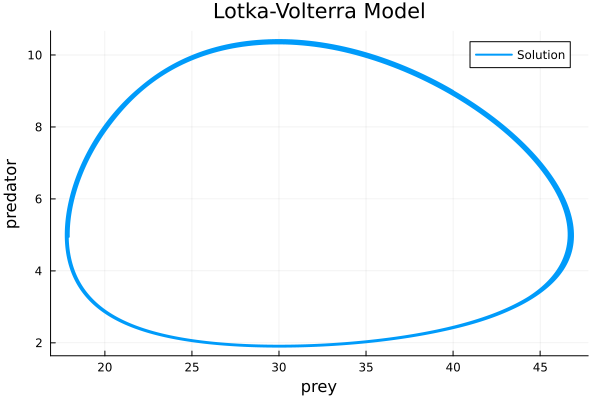

In [ ]:
## Lotka-Volterra equations
@parameters α β γ δ
@independent_variables  t
@variables x(t) y(t)
Dt = Differential(t)
eqs = [
    Dt(x) ~ α * x - β * x * y,
    Dt(y) ~ δ * x * y - γ * y,
]
@named sys = ODESystem(eqs, t, [x, y], [α, β, γ, δ])
sys = complete(sys)
params =  Dict([α => 0.1, 
                β => 0.02, 
                δ => 0.01,
                γ => 0.3])

u0 = Dict([x => 40.0, y => 9.0])
tspan = (0.0, 200.0)
dt = 0.1

sys = complete(sys)
odefun = ODEFunction(sys, unknowns(sys), parameters(sys))
prob = ODEProblem(odefun, [40.0, 9.0], tspan, [0.1, 0.02, 0.01, 0.3])
sol = solve(prob, Tsit5(), saveat=dt)
data = hcat(sol.u...)'
plot(sol, vars=(x, y), xlabel="prey", ylabel="predator",
     title="Lotka-Volterra Model", label="Solution",
     legend=:topright, linewidth=2, markersize=4)


In [184]:
odefun([0.0,0.0], [40.0, 9.0], [0.1, 0.02, 0.01, 0.3], 0.0)

2-element Vector{Float64}:
 -3.2
  0.9000000000000004

### Random noise
We add random noise to the Lotka-Volterra equations to simulate a more realistic scenario.


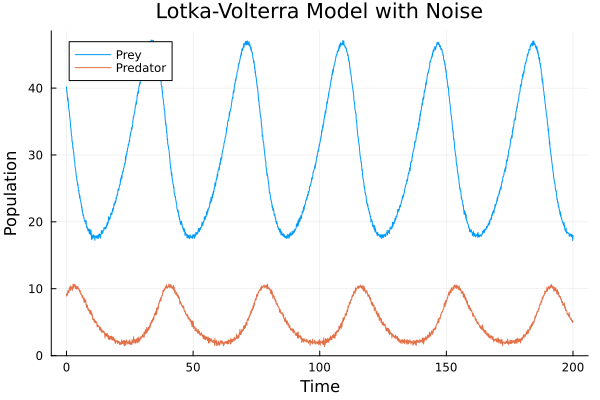

In [24]:
using Random
rng = Random.default_rng()
Random.seed!(1234)
noise = 0.2 * randn(size(data))
data = data .+ noise
time = sol.t
plot(time, data, label=["Prey" "Predator"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Noise")

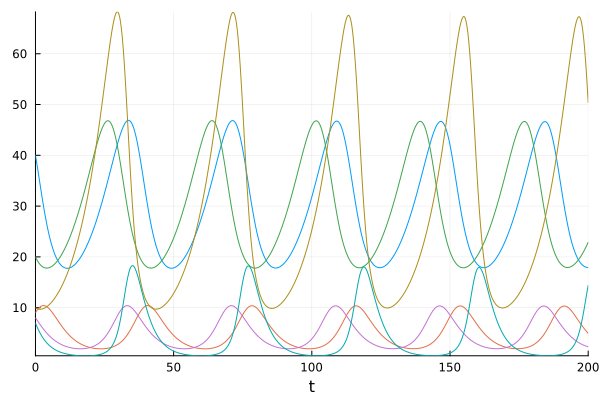

In [ ]:

### ENSEMBLE DATA ###

initial_conditions  = [
    [40.0, 9.00],
    [20.0, 8.0],
    [10, 7.0], 
]
function prob_func(prob, i, repeat)
    remake(prob, u0 = initial_conditions[i])
end

ensemble_prob = EnsembleProblem(prob, prob_func = prob_func)
sim = solve(ensemble_prob, Tsit5(), EnsembleDistributed(), trajectories = 3, saveat = time)
# ensemble_data = hcat([sim.u[1].u; sim.u[2].u; sim.u[3].u]...)
#ensemble_data = ensemble_data .+ randn(size(ensemble_data)) * 0.02 # Add noise to the ensemble data'
plot(sim)
#save dat as named tuple


In [5]:
using Catalyst
using KolmogorovArnold
using ComponentArrays

In [ ]:
using Lux
Random.seed!(1234)
# Gaussian RBF as activation
rbf(x) = exp.(-(x.^2))

U = Lux.Chain(
    Lux.Dense(2,5,rbf; init_weight =  kaiming_normal),
    Lux.Dense(5,5, rbf, init_weight = kaiming_normal),
    Lux.Dense(5,5, rbf, init_weight = kaiming_normal),
    Lux.Dense(5,2, rbf, init_weight = kaiming_normal),
)
p_nn, st_nn = Lux.setup(rng, U)

((layer_1 = (weight = Float32[-0.3597289 -0.6856709; 1.0872085 2.054763; … ; 0.7189099 -0.30490124; 0.42024717 0.461695], bias = Float32[0.6839456, 0.11063666, 0.5402172, 0.3223487, 0.3691989]), layer_2 = (weight = Float32[0.06681994 0.096152365 … -0.4614094 0.6903243; -0.34224916 -0.56881386 … -0.40241653 0.77162343; … ; -0.5922409 0.18877503 … 0.4874355 1.0904734; -0.3907287 -1.247884 … -0.76776314 0.09658124], bias = Float32[-0.09054065, 0.30903766, 0.41225228, -0.13506278, 0.063907035]), layer_3 = (weight = Float32[0.36322206 1.3756555 … 0.59790343 0.50240624; -0.49872366 1.1383672 … 0.35233498 0.5440807; … ; 0.5283514 0.7913283 … -0.5133892 0.7389771; 1.1035775 -0.6702465 … 0.19106293 -0.0026604047], bias = Float32[0.020446224, -0.32674742, 0.36837876, 0.028531417, 0.080955364]), layer_4 = (weight = Float32[0.4637196 0.07468518 … -0.45366946 0.01610096; 0.63299024 -0.42324442 … 1.1897047 -0.44075283], bias = Float32[0.02214501, 0.2855495])), (layer_1 = NamedTuple(), layer_2 = Name

In [7]:
p_combined = (;ode = [0.1], nn = p_nn) # combine the parameters into a single dictionary
typeof(p_combined)

@NamedTuple{ode::Vector{Float64}, nn::@NamedTuple{layer_1::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_2::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_3::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_4::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}}}

In [218]:
basis_func = KolmogorovArnold.rbf # rbf, rswaf, iqf (radial basis funcs, reflection switch activation funcs, inverse quadratic funcs)
normalizer = softsign # sigmoid(_fast), tanh(_fast), softsign
kan1 = Chain(
    KDense( 2, 40, 10; use_base_act = true, basis_func, normalizer),
    KDense(40, 40, 10; use_base_act = true, basis_func, normalizer),
    KDense(40,  2, 10; use_base_act = true, basis_func, normalizer),
) # 18_490 parameters plus 30 states.
p_kan, st_kan = Lux.setup(rng, kan1)
st_kan

(layer_1 = (grid = Float32[-1.0, -0.7777778, -0.5555556, -0.33333334, -0.11111111, 0.11111111, 0.33333334, 0.5555556, 0.7777778, 1.0],), layer_2 = (grid = Float32[-1.0, -0.7777778, -0.5555556, -0.33333334, -0.11111111, 0.11111111, 0.33333334, 0.5555556, 0.7777778, 1.0],), layer_3 = (grid = Float32[-1.0, -0.7777778, -0.5555556, -0.33333334, -0.11111111, 0.11111111, 0.33333334, 0.5555556, 0.7777778, 1.0],))

### Hidden Dynamics with UDEs

In [26]:
known_eqs = [
    Dt(x) ~ α * x
    Dt(y) ~ -γ * y
]
unknown_eqs = [
    Dt(x) ~ -β * x * y,
    Dt(y) ~ δ * x * y,
]
deviance = 0.1 # deviance for the unknown equations
params_guess_known = Dict([α => 0.1, # + deviance * randn()
                        γ => 0.3, # + deviance * randn()])
                        ])

params_guess_unknown = Dict([β => 0.02,# + deviance * randn()
                        δ => 0.01 # + deviance * randn()])
                        ])


@named sys_known = ODESystem(known_eqs, t, [x, y], [α, γ], defaults = params_guess_known)
@named sys_unknown = ODESystem(unknown_eqs, t, [x, y], [β, δ], defaults = params_guess_unknown)
sys_known = complete(sys_known)
sys_unknown = complete(sys_unknown)

Model sys_unknown:
Equations (2):
  2 standard: see equations(sys_unknown)
Unknowns (2): see unknowns(sys_unknown)
  x(t)
  y(t)
Parameters (2): see parameters(sys_unknown)
  β [defaults to 0.02]
  δ [defaults to 0.01]

In [ ]:
""" HiddenODE is a system that combines an ODE system with a surrogate model (SINDy or neural network)."""
mutable struct HiddenODE
    """ The known underlying ODE system."""
    sys::ODESystem
    """ The surrogate model, which can be a normal ODESystem, SINDy model, or a Lux neural network."""
    surrogate::Union{ModelingToolkit.AbstractTimeDependentSystem, Lux.Chain}
    """ Discrete events that trigger during the simulation."""
    events::Vector
    """ Observables that are computed during the simulation."""
    observables::Vector
    """ Random number generator for reproducibility."""
    rng ::Random.AbstractRNG
    
    """ Construct a HiddenODE system with a SINDy/ODE surrogate model. """
    HiddenODE(sys::ODESystem, surrogate::T;
                events::Vector = [], 
                observables::Vector = [],
                rng::Random.AbstractRNG = Random.default_rng(1234)
                ) where 
                {T <: ModelingToolkit.AbstractTimeDependentSystem} = 
        new(sys, surrogate, events, observables, rng)


    """   Construct a HiddenODE system with a Lux neural network surrogate model."""
    HiddenODE(sys::ODESystem, surrogate::T,; 
               events::Vector = [], 
               observables::Vector = [],
               rng::Random.AbstractRNG = Random.default_rng(1234)
               ) where 
               {T <: Lux.Chain} =    
        new(sys, surrogate, events, observables, rng)
end

# Convert a dictionary to a NamedTuple (for use with ComponentArrays with ModelingToolkit)
NamedTuple(dict::Dict) = (; (Symbol(string(k)) => v for (k, v) in dict)...) 

#### HIDDEN ODE METHODS ####

function init_params(model::HiddenODE)
    @unpack sys, surrogate, rng = model
    
    # Initialize parameters for the ODE system
    ode_ps = init_params(sys)
    # Initialize parameters for the surrogate model
    surrogate_ps = init_params(surrogate; rng)
    
    # Combine the parameters into a NamedTuple
    combined_ps = (; ode = ode_ps, surrogate = surrogate_ps)
    return ComponentVector{Float64}(combined_ps)
end

#create the ODE function for the HiddenODE system
function ODEFunction(model::HiddenODE)
    @unpack sys, surrogate, rng = model
    # Get the derivative function for the ODE system
    ode_fun = derivative_function!(sys)
    # Get the surrogate derivative function
    surrogate_fun = derivative_function!(surrogate; rng = rng)

    du1 = zeros(length(unknowns(sys))) # Initialize du1 for the ODE system
    du2 = copy(du1) # Initialize du2 for the surrogate model
    function update_du!(du, u, p, t)
        # Compute the ODE derivatives
        ode_fun(du1, u, p.ode, t) 
        # Compute the surrogate derivatives
        surrogate_fun(du2, u, p.surrogate, t) 
        # Combine the derivatives   
        du.= du1 .+ du2 
        return du  
    end
    return deepcopy(update_du!)
end


### ODE SYSTEM METHODS ###
function init_params(sys::ODESystem; randfun = rand, rng = Random.default_rng(1234))
    if ModelingToolkit.has_defaults(sys)
        defaults = ModelingToolkit.get_defaults(sys)
        params = parameters(sys)
        # Initialize parameters with defaults (NamedTuple))
        return (; (Symbol(string(p)) => defaults[p] for p in parameters(sys) if p in keys(defaults))...)
    else
        # If no defaults, return an empty random values
        return (; (Symbol(string(p)) => randfun() for p in parameters(sys))...)
    end
end


function derivative_function!(sys::ODESystem; rng = Random.default_rng(1234))
    return ODEFunction(sys)
end

### NEURAL NETWORK METHODS ###
function init_params(nn::Lux.Chain; rng = Random.default_rng(1234))
    # Get the parameters of the Lux model
    return Lux.initialparameters(rng, nn)
end

function derivative_function!(nn::Lux.Chain; rng = Random.default_rng(1234))
    # Create a function that computes the derivatives of the Lux model
    st = Lux.initialstates(rng, nn)
    #NeuralODE. The output of the neural network is a vector of derivatives. Network only depends on state and network parameters.
    du = (du, u, p, t) -> first(nn(u, p, st))
    return deepcopy(du)
end


derivative_function! (generic function with 2 methods)

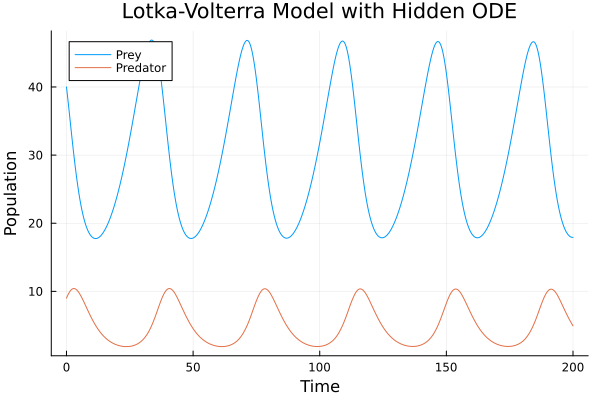

In [215]:
hmodel = HiddenODE(sys_known, sys_unknown)

initp = init_params(hmodel)
odefun = ODEFunction(hmodel)
prob = ODEProblem(odefun, [40.0, 9.0], tspan, initp)
sol = solve(prob, Tsit5(), saveat=dt)
data = hcat(sol.u...)'
plot(sol.t, data, label=["Prey" "Predator"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Hidden ODE")


In [197]:
odefun = ODEFunction(hmodel)
odefun([10.,10.], [40.0, 12.0], initp, 0.0)

2-element Vector{Float64}:
  4.678091042878018
 -2.6202856501618688

In [178]:
du1 = zeros(2)
du2 = zeros(2)
du1 = ode_fun(du1, u0vals, initp.ode, 0.0)
du2 = surrogate_fun(du2, u0vals, initp.surrogate, 0.0)
println("ODE derivatives: ", du1)
println("Surrogate derivatives: ", du2)
println("Combined derivatives: ", du1 .+ du2)
println("Combined derivatives (as function): ", update_du!(zeros(2), u0vals, initp, 0.0))

ODE derivatives: [4.0, -2.6999999999999997]
Surrogate derivatives: [-7.2, 3.6]
Combined derivatives: [-3.2, 0.9000000000000004]
Combined derivatives (as function): [-14.4, 7.2]


In [162]:
initp

ComponentVector{Float64}(ode = (α = 0.1, γ = 0.3), surrogate = (β = 0.02, δ = 0.01))